# 06 · Speed and client resize

## Overview

"How fast is it?" has more than one answer. One photo can be fast while many photos at once are
slow, and the first photo is always slower than the rest. In this notebook you measure speed the
right way with `visionserve bench`, and you see how the Python client makes large photos faster
by shrinking them before upload.

**What you will learn**

- What latency, throughput, p50 and p95 mean.
- How to run `visionserve bench` in this process and through the server.
- What changes with 1 or 4 requests at the same time.
- How much faster a GPU is than the CPU (if you have a GPU).
- What client-side resize does with a large photo: `resize="auto"` and `resize="off"`.
- The loopback rule, and when to turn client resize off.

**Time:** about 20 minutes.

**Before you start**

- A running VisionServe server and the `visionserve` program (see notebook 00 and the setup in
  `README.md`).
- The models `rf-detr` and `grounding-dino` (the notebook downloads them if they are missing;
  `grounding-dino` is about 700 MB).
- A GPU is optional. Without one, the notebook measures the CPU only.

**Steps**

1. Set up, and a few words
2. A first benchmark
3. CPU and GPU
4. Through the server: 1 or 4 requests at a time
5. A large photo: client resize on and off
6. The loopback rule
7. When to turn client resize off
8. All timings in one table
9. Clean up

## 1. Set up, and a few words

Some words we use in this notebook:

- **Latency**: the time for one request, from sending the photo to getting the answer. Smaller is
  better. Measured in milliseconds (ms): 1000 ms = 1 second.
- **Throughput**: how many requests are finished per second (req/s). Larger is better.
- **p50** (the median): half of the requests were faster than this. **p95**: 95 % were faster.
  p95 shows the slow cases; look at it if you have a deadline.
- **Concurrency**: how many requests are in progress at the same time.
- **Warm-up**: the first requests are slower (the GPU prepares its work and memory). A fair
  measurement skips them.
- **Cold load**: the time to load the model before the first request.

In [1]:
import io
import json
import os
import shutil
import statistics
import time
from pathlib import Path

from PIL import Image

import handson as ho
from visionserve import Client

client = ho.connect()
for name in ["rf-detr", "grounding-dino"]:
    ho.ensure_model(client, name)

WORK = Path("work-06")
WORK.mkdir(exist_ok=True)
PHOTOS = ho.photo("cat").parent          # hands-on/images: 8 sample photos


def bench_json(*args):
    """Run visionserve bench with --json and return the result as a dictionary."""
    out = ho.run_cli("bench", *args, "--json", echo=False)
    return json.loads(out[out.index("{"): out.rindex("}") + 1])


def row(label, r):
    """One table row from a bench result."""
    s = r["summary"]
    return [label, s["device"], f'{s["latency_ms"]["p50_ms"]:.1f}', f'{s["latency_ms"]["p95_ms"]:.1f}',
            f'{s["throughput_rps"]:.1f}', f'{s["server_ms"]["p50_ms"]:.1f}']


HEADERS = ["run", "device", "p50 ms", "p95 ms", "req/s", "model's own p50 ms"]

Connected to VisionServe at http://127.0.0.1:11785: {'status': 'ok'}
Model 'rf-detr' is installed (state: loaded).
Model 'grounding-dino' is installed (state: available).


**What you see**

The server and model lines. `bench_json` and `row` are small functions for the tables below: they
run `visionserve bench --json` and keep the main numbers.

<details><summary><b>In detail</b></summary>

Speed numbers belong to one machine. The same model is many times faster on a big GPU than on a
small CPU, and a GPU shared with other jobs gives slower and less stable numbers. Always measure
on the machine you will use, and write down which machine it was.

More: [Measure speed](https://mtbui2010.github.io/visionserve/guides/measure-speed/).

</details>

## 2. A first benchmark

`visionserve bench MODEL` loads the model **in this process** (like `visionserve run`, no server
needed), sends a few warm-up photos, then times 50 requests, one at a time. `--images` gives a
folder of photos to send; without it, `bench` uses a synthetic 640 × 480 image.

In [2]:
out = ho.run_cli("bench", "rf-detr", "--images", PHOTOS)

$ visionserve bench rf-detr --images images


bench: loading rf-detr (in-process) ...


bench: 50 requests at concurrency 1 ...


PASS: p50 16.4 ms, 60.7 req/s on gpu:0


  device (EP used)         gpu:0


...

  GPU memory               this process (nvidia-smi)


Next steps


  Throughput under parallel load: `visionserve bench rf-detr --concurrency 4`.


  Smaller / faster variants: `visionserve optimize rf-detr --target jetson-orin --images DIR` on a PC, then bench the result here.


(exit code 0)


**What you see**

The first line is the answer: `PASS`, the median time per photo, the throughput, and the device.
Then, line by line:

| Line | In plain words |
|---|---|
| `device (EP used)` | Where it really ran: `gpu:0` (the first GPU, with CUDA) or `cpu`. **EP** = execution provider, the ONNX Runtime part that runs the model on one kind of hardware. |
| `cold load` | Time to load the model: paid once, when the server starts or after the model was unloaded. |
| `first request` | The first photo is much slower: the GPU chooses its methods and takes memory. |
| `latency p50 / p95 / p99` | Time per photo. For rf-detr on our test GPU (shared with other jobs), between about 15 and 40 ms from run to run. |
| `server-side p50 / p95` | The model's own time (prepare + run + decode). In-process it is the same as the latency. |
| `throughput` | Photos per second, one at a time. |
| `process memory`, `GPU memory` | The memory this process uses. |

The `Findings` line reminds you: the numbers are for this machine and its current load.

<details><summary><b>In detail</b></summary>

- `--requests N` (default 50) and `--warmup N` (default 3) change how many requests are timed and
  skipped.
- `--report bench.html` writes a page with the latency histogram (how many requests took each
  time) and the time of each request in order (a drift shows warm-up or other load).
- If `p99` is more than twice `p50`, something else uses the GPU or CPU, or each new photo size
  is slow the first time. Raise `--warmup`, or use photos at your camera's size.

More: [Measure speed, "Reading the result"](https://mtbui2010.github.io/visionserve/guides/measure-speed/#reading-the-result).

</details>

## 3. CPU and GPU

`--ep cpu` forces the CPU. We compare it with the default (the GPU when there is one). The CPU
is slow, so we time only 20 requests there.

In [3]:
auto = bench_json("rf-detr", "--images", PHOTOS)
rows = [row("default (cuda, else cpu)", auto)]
if auto["summary"]["device"].startswith("gpu"):
    cpu = bench_json("rf-detr", "--images", PHOTOS, "--ep", "cpu", "--requests", "20")
    rows.append(row("--ep cpu", cpu))
    print(f"The GPU is {cpu['summary']['latency_ms']['p50_ms'] / auto['summary']['latency_ms']['p50_ms']:.0f} "
          "times faster than the CPU for one photo.")
else:
    print("No GPU was used on this machine: the default already ran on the CPU.")
ho.table(rows, HEADERS)

The GPU is 21 times faster than the CPU for one photo.


run,device,p50 ms,p95 ms,req/s,model's own p50 ms
"default (cuda, else cpu)",gpu:0,16.2,20.0,60.7,16.2
--ep cpu,cpu,342.0,715.2,2.8,342.0


**What you see**

A table with one row per run. With a GPU, the GPU row is many times faster than the CPU row (on
our test machine, an RTX A6000 with a busy 48-core CPU, more than 10 times). The answers are the
same: only the speed changes.

If the default run says `cpu` although the machine has a GPU, `bench` gives a `WARN`. The usual
cause is an ONNX Runtime library without CUDA.

<details><summary><b>In detail</b></summary>

- `--ep cuda` says "I expect the GPU": a silent fall-back to the CPU then becomes a `WARN`.
- `--ep tensorrt` tries NVIDIA TensorRT first. It can be faster, but it measured 6.8 mAP lower on
  GroundingDINO, so it is off unless you ask for it.
- Every answer from the server has a `device` field (`cpu`, `gpu:0`, `gpu:0+trt`), so you can
  also see it in your own code.

More: [Measure speed, "If it says WARN or FAIL"](https://mtbui2010.github.io/visionserve/guides/measure-speed/#if-it-says-warn-or-fail)
and [Model files and ONNX Runtime](https://mtbui2010.github.io/visionserve/concepts/onnx/).

</details>

## 4. Through the server: 1 or 4 requests at a time

Your users do not run the model in their own process: they send photos to the server over HTTP.
`--server URL` times these whole requests, upload included. `--concurrency 4` keeps 4 requests
in progress at the same time, like 4 users.

In [4]:
rows = []
for c in (1, 4):
    r = bench_json("rf-detr", "--images", PHOTOS, "--server", client.host, "--concurrency", str(c))
    rows.append(row(f"server, concurrency {c}", r))
ho.table(rows, HEADERS)

run,device,p50 ms,p95 ms,req/s,model's own p50 ms
"server, concurrency 1",gpu:0,35.1,64.7,25.7,19.0
"server, concurrency 4",gpu:0,43.1,62.9,85.5,24.6


**What you see**

- **Concurrency 1**: the latency is a little higher than in-process, because of the HTTP request
  and the photo decoding. The model's own time (last column) is about the same as before.
- **Concurrency 4**: the throughput (req/s) goes **up** a lot: the server keeps the GPU busy
  while other requests are uploaded and decoded. The latency of one request changes much less.
  It often goes up a little, because a request sometimes waits for another one; on a busy machine
  it can also stay the same or vary from run to run.

So "faster" depends on the question. For one camera that needs a quick answer, look at p50 and
p95 at concurrency 1. For many users or cameras, look at req/s at a higher concurrency.

<details><summary><b>In detail</b></summary>

- The difference between the latency and the model's own time is what a request costs outside
  the model: upload, decoding the photo, and waiting behind other requests.
- `--reload` unloads the model first, to measure the cold load through the server too.
- `bench` sends your photos as they are. It does not use the client-side resize of the next
  section, so it measures the upload of the size you give it.

More: [Measure speed, "Through the server"](https://mtbui2010.github.io/visionserve/guides/measure-speed/#through-the-server-as-your-clients-see-it).

</details>

## 5. A large photo: client resize on and off

A phone or camera photo is often 12 megapixels (4000 × 3000). But RF-DETR shrinks every photo to
560 × 560 anyway. So most pixels of a large photo are uploaded and decoded, then thrown away.

The Python client (SDK 0.2.0 and newer) can shrink a large photo **before** it uploads it. This
is **client-side resize**. It is on by default (`resize="auto"`). The server tells the client, for
each model, how large a photo is still useful (`client.useful_side(model)`). The answer is always
mapped back, so every box is still in the pixels of your original photo.

We make a 4000 × 3000 photo by enlarging one of the sample photos, then send it both ways.

kitchen-4000x3000.jpg: 1.6 MB
useful size for rf-detr (longest side, shortest side): (None, 1120)


auto  sent 1493 x 1120  upload 0.25 MB   server   21 ms   whole request  210 ms   (+ about 20 ms upload at 100 Mbit/s)
off   sent as it is     upload 1.55 MB   server   37 ms   whole request  235 ms   (+ about 124 ms upload at 100 Mbit/s)

auto: ClientResize(original_width=4000, original_height=3000, sent_width=1493, sent_height=1120, jpeg_quality=90, reason='hint')
off:  None
auto found 6 objects, off found 7


class,conf (auto),bbox (auto),conf (off),bbox (off)
chair,0.906,"[3402, 1113, 382, 593]",0.907,"[3403, 1113, 381, 593]"
chair,0.899,"[3018, 1074, 289, 306]",0.898,"[3018, 1074, 289, 306]"
bottle,0.709,"[968, 1135, 137, 239]",0.725,"[968, 1135, 137, 239]"
bowl,0.675,"[2563, 1219, 237, 122]",0.677,"[2563, 1219, 237, 123]"
sink,0.657,"[878, 1579, 983, 829]",0.662,"[879, 1581, 976, 827]"
bottle,0.612,"[770, 1128, 155, 286]",0.618,"[770, 1128, 155, 286]"


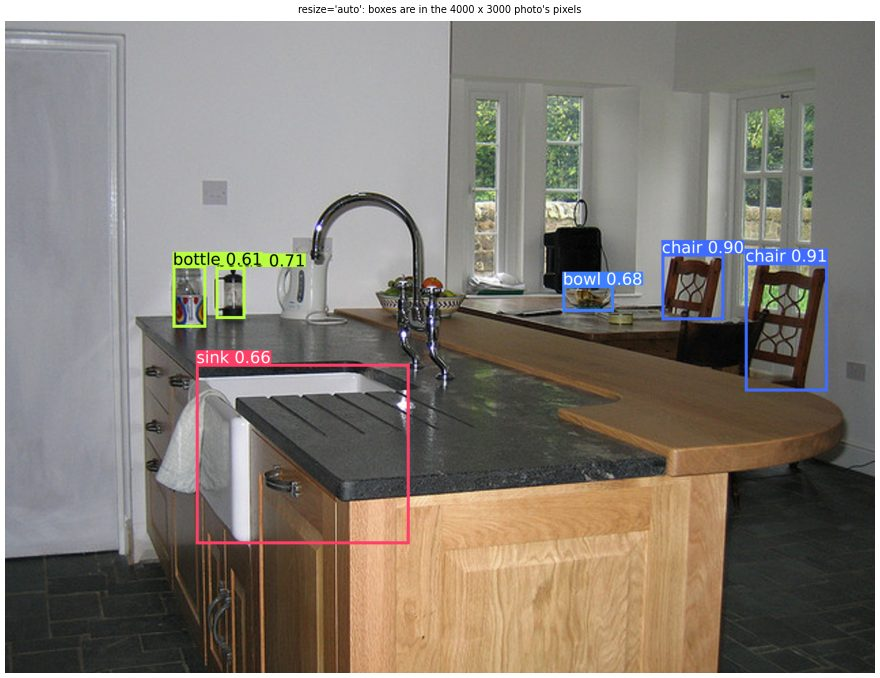

In [5]:
big = WORK / "kitchen-4000x3000.jpg"
Image.open(ho.photo("kitchen")).resize((4000, 3000), Image.BICUBIC).save(big, quality=95)
print(f"{big.name}: {big.stat().st_size / 1e6:.1f} MB")
print("useful size for rf-detr (longest side, shortest side):", client.useful_side("rf-detr"))

auto_client = client                                 # resize="auto" is the default
off_client = Client(client.host, resize="off")


def upload_bytes(path, cr):
    """Bytes the client uploads: the file itself, or (about) the smaller JPEG it makes."""
    if cr is None or not cr.resized:
        return path.stat().st_size
    buf = io.BytesIO()
    Image.open(path).convert("RGB").resize((cr.sent_width, cr.sent_height), Image.LANCZOS).save(
        buf, "JPEG", quality=cr.jpeg_quality or 90)
    return len(buf.getvalue())


def compare(model, image, n=7, **kw):
    """Send the same photo n times with resize "auto" and "off", in turns. Median times in ms."""
    clients = {"auto": auto_client, "off": off_client}
    for c in clients.values():
        c.predict(model, image, **kw)                # one untimed request each (warm-up)
    wall, server, last = {"auto": [], "off": []}, {"auto": [], "off": []}, {}
    for _ in range(n):
        for key, c in clients.items():
            t0 = time.perf_counter()
            last[key] = c.predict(model, image, **kw)
            wall[key].append((time.perf_counter() - t0) * 1000)
            server[key].append(last[key].duration_ms)
    out = {}
    for key in clients:
        cr = last[key].client_resize
        sent = f"{cr.sent_width} x {cr.sent_height}" if cr and cr.resized else "as it is"
        nbytes = upload_bytes(Path(image), cr)
        out[key] = {"result": last[key], "sent": sent, "MB": nbytes / 1e6,
                    "server_ms": statistics.median(server[key]), "wall_ms": statistics.median(wall[key]),
                    "net_ms": nbytes * 8 / 100e6 * 1000}  # upload time at 100 Mbit/s
        print(f"{key:<4}  sent {sent:<12} upload {nbytes / 1e6:4.2f} MB   server {out[key]['server_ms']:4.0f} ms   "
              f"whole request {out[key]['wall_ms']:4.0f} ms   (+ about {out[key]['net_ms']:.0f} ms upload at 100 Mbit/s)")
    return out


jpg = compare("rf-detr", big)
res_auto, res_off = jpg["auto"]["result"], jpg["off"]["result"]
print("\nauto:", res_auto.client_resize)
print("off: ", res_off.client_resize)



def iou(a, b):
    """Overlap of two [x, y, w, h] boxes: 1 = the same box, 0 = no overlap."""
    ix = max(0, min(a[0] + a[2], b[0] + b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[1] + a[3], b[1] + b[3]) - max(a[1], b[1]))
    inter = ix * iy
    return inter / (a[2] * a[3] + b[2] * b[3] - inter)


rows = []
for d in res_auto.detections:                         # find the same object in the "off" answer
    same = [o for o in res_off.detections if o.cls == d.cls]
    o = max(same, key=lambda o: iou(d.bbox, o.bbox), default=None)
    rows.append([d.cls, f"{d.conf:.3f}", str([round(v) for v in d.bbox]),
                 f"{o.conf:.3f}" if o else "-", str([round(v) for v in o.bbox]) if o else "-"])
print(f"auto found {len(res_auto.detections)} objects, off found {len(res_off.detections)}")
ho.table(rows, ["class", "conf (auto)", "bbox (auto)", "conf (off)", "bbox (off)"])
ho.show(big, res_auto, title="resize='auto': boxes are in the 4000 x 3000 photo's pixels")

**What you see**

- The file is a few MB. `useful_side` is `(None, 1120)`: for rf-detr a photo is useful up to a
  **shorter side** of 1120 pixels (2 × 560). Larger photos are shrunk.
- `auto`: `client_resize` says what the client did: the original was 4000 × 3000, it **sent**
  1493 × 1120 as JPEG, `reason='hint'` (it used the server's hint).
- `off`: `client_resize` is `None`: the photo went out as it was.
- The two lines of numbers (medians of 7 requests each, sent in turns):
  - **upload**: `auto` sends a few hundred kB instead of the whole file.
  - **server**: the server's own time (prepare the photo, run the model, decode the answer) is
    shorter with `auto`: it has far fewer pixels to shrink to 560 × 560.
  - **whole request**: on this machine the two are close. Here the server is on the same machine
    (loopback), so the upload costs nothing, and with `auto` the client spends time to decode
    and shrink the photo. Which one wins changes from run to run on a busy machine.
  - **upload at 100 Mbit/s**: an estimate for a client on another machine. There, the full file
    costs over 100 ms more per photo. This is where `auto` wins clearly.
- The table: the same objects, with almost the same confidence and boxes within a few pixels of
  each other, all in the pixels of the 4000 × 3000 photo. One answer may have one box more: a box
  with a score very close to the threshold (0.5) can fall on either side.
- The picture: the boxes sit on the objects of the large photo. You do not need to scale
  anything yourself.

<details><summary><b>In detail</b></summary>

- How the client shrinks: it decodes the JPEG at a reduced size (a fast feature of the JPEG
  decoder), rotates it by its EXIF tag the way the server would, shrinks it with a Lanczos filter
  (a high-quality resize), and sends it as JPEG with quality 90.
- `Client(resize=1280)` shrinks every photo to a longer side of 1280, whatever the model.
  `jpeg=False` sends lossless PNG instead of JPEG (larger).
- Models whose output needs the full photo get no hint and always receive the full photo: every
  model that returns masks (SAM family), OCR, grasping, depth.
- Our photo is enlarged from a small one, so it is smooth and compresses well. A real 12-megapixel
  camera photo is larger on disk, and the saving is larger too.

More: [Python client, "Client-side resizing"](https://mtbui2010.github.io/visionserve/clients/python/#client-side-resizing-on-by-default).

</details>

## 6. The loopback rule

**Loopback** means "this same machine": the addresses `localhost`, `127.0.0.1` (and the rest of
127.x.x.x) and `::1`. When the server is on the same machine, the upload costs almost nothing.
Shrinking then only saves the server's decoding, and the client must decode the full photo to
shrink it. A small shrink costs more than it saves.

So on loopback, `resize="auto"` shrinks a photo only when that at least **halves** its sides.
GroundingDINO uses photos up to a shorter side of 1600 pixels: 1600 / 3000 = 0.53, more than half.

In [6]:
print("useful size for grounding-dino:", client.useful_side("grounding-dino"))
print("this client talks to:", client.host)
gd = client.predict("grounding-dino", big, prompt="sink. chair. bottle.")
print("grounding-dino:", gd.client_resize)
print(f"found {len(gd.detections)} objects in {gd.duration_ms:.0f} ms (server time) on {gd.device}")

useful size for grounding-dino: (None, 1600)
this client talks to: http://127.0.0.1:11785


grounding-dino: ClientResize(original_width=4000, original_height=3000, sent_width=4000, sent_height=3000, jpeg_quality=None, reason='loopback: scale 0.53 > 0.5, sent as is')
found 8 objects in 857 ms (server time) on gpu:0


**What you see**

- `useful_side` for grounding-dino is `(None, 1600)`.
- `client_resize` shows `sent_width=4000, sent_height=3000` and the reason
  `loopback: scale 0.53 > 0.5, sent as is`: the client did **not** shrink the photo, because the
  server is on this machine and the shrink would be small.
- For rf-detr (section 5) the scale was 1120 / 3000 = 0.37, below 0.5, so it shrank even on
  loopback.
- With a server on another machine, the rule does not apply: the client always shrinks to the
  hint, because then the upload over the network is the main cost.

<details><summary><b>In detail</b></summary>

- The rule was measured: GroundingDINO on a 4000 × 3000 photo was 1.7 to 1.9 times **slower**
  shrunk than sent whole, on localhost. Over a 100 Mbit/s network, shrinking wins clearly.
- The client does not look up host names: `localhost`, `127.x.x.x` and `::1` count as loopback;
  any other name or address counts as remote.
- An explicit `resize=N` is always applied, on loopback too.

More: [Python client, "The loopback rule"](https://mtbui2010.github.io/visionserve/clients/python/#the-loopback-rule).

</details>

## 7. When to turn client resize off

Turn it off (`Client(resize="off")`, or `predict(..., resize="off")` for one call) when:

- **The model must see small details at full size**, for example text (OCR). OCR models get no
  hint, so the client already sends them the full photo, but your own model may need it too.
- **You compare with your training code** (notebook 05): compare the same pixels.
- **Large PNG files on the same machine**: the client must decode the whole PNG to shrink it, and
  PNG is slow to decode. Let us measure it.

In [7]:
print("useful size for paddle-ocr:", client.useful_side("paddle-ocr"), "(no hint: always the full photo)")

big_png = WORK / "kitchen-4000x3000.png"
Image.open(big).save(big_png)
print(f"{big_png.name}: {big_png.stat().st_size / 1e6:.1f} MB")
png = compare("rf-detr", big_png)

useful size for paddle-ocr: (None, None) (no hint: always the full photo)


kitchen-4000x3000.png: 6.9 MB


auto  sent 1493 x 1120  upload 0.25 MB   server   24 ms   whole request  643 ms   (+ about 20 ms upload at 100 Mbit/s)
off   sent as it is     upload 6.93 MB   server   33 ms   whole request  598 ms   (+ about 554 ms upload at 100 Mbit/s)


**What you see**

- `paddle-ocr` has no hint (`(None, None)`): its photos are never shrunk.
- The PNG file is several times larger than the JPEG. **PNG** is a lossless format: it keeps
  every pixel exactly, so it is large and slow to decode.
- With `auto` the client decodes the whole PNG and shrinks it; with `off` the server decodes it.
  On the same machine there is no upload cost to save, so `auto` gains little or nothing here,
  and it can be slower.
- The estimate for a network tells the other side: uploading the full PNG at 100 Mbit/s costs
  about half a second per photo. On another machine, keep `auto`.

<details><summary><b>In detail</b></summary>

- The docs measured this on a real 12-megapixel PNG: on localhost, RF-DETR was slower with
  `auto` than with `off`. JPEG files are faster to shrink, because the JPEG decoder can decode
  at a reduced size directly; PNG has no such shortcut.
- `preprocess()` (notebook 03) sends the photo as it is by default, for the same reason as the
  comparison with training: you want the same pixels.
- On the command line the same switches exist: `--resize off`, `--no-jpeg`, `--jpeg-quality Q`.

More: [Python client, "What it costs and saves"](https://mtbui2010.github.io/visionserve/clients/python/#what-it-costs-and-saves).

</details>

## 8. All timings in one table

In [8]:
rows = []
for photo_name, runs in (("JPEG 4000 x 3000", jpg), ("PNG 4000 x 3000", png)):
    for key in ("auto", "off"):
        r = runs[key]
        rows.append([photo_name, key, r["sent"], f'{r["MB"]:.2f}', f'{r["server_ms"]:.0f}',
                     f'{r["wall_ms"]:.0f}', f'{r["wall_ms"] + r["net_ms"]:.0f}'])
ho.table(rows, ["photo (rf-detr)", "resize", "sent", "upload MB", "server ms", "whole request ms (here)",
                "+ upload at 100 Mbit/s ms (estimate)"])

photo (rf-detr),resize,sent,upload MB,server ms,whole request ms (here),+ upload at 100 Mbit/s ms (estimate)
JPEG 4000 x 3000,auto,1493 x 1120,0.25,21,210,230
JPEG 4000 x 3000,off,as it is,1.55,37,235,359
PNG 4000 x 3000,auto,1493 x 1120,0.25,24,643,664
PNG 4000 x 3000,off,as it is,6.93,33,598,1153


**What you see**

Four rows, one per run. Read the columns from left to right:

- **upload MB**: with `auto` the client always sends much less.
- **server ms**: the server's own time is shorter with `auto` (fewer pixels to shrink).
- **whole request ms (here)**: on loopback the difference is small, and it can go either way:
  the client's own work for `auto` takes back much of what the server saves. For the PNG, `off`
  is often faster here.
- **+ upload at 100 Mbit/s**: the same request from another machine (an estimate: the time here
  plus the upload). Now `auto` is clearly faster, most of all for the large PNG.

Your numbers depend on your machine and its load. Run the cells again to see how much they
change.

## 9. Clean up

In [9]:
shutil.rmtree(WORK, ignore_errors=True)
print("deleted", WORK)

deleted work-06


## Recap

- **Latency** is the time of one request (look at p50 and p95); **throughput** is requests per
  second. They answer different questions.
- `visionserve bench MODEL` measures in this process; `--server URL` measures whole HTTP requests,
  as your users see them; `--concurrency N` sends N at a time.
- The first request and the cold load are slower; `bench` reports them apart.
- The GPU is many times faster than the CPU for the same answers. `--ep cpu` forces the CPU.
- The Python client shrinks large photos before upload (`resize="auto"`), and maps every box back
  to your photo's pixels. `client_resize` says what it did.
- On loopback it shrinks only when that halves the sides. Turn it off for full-size details, for
  comparisons with training, and for large PNG files on the same machine.

## Next

- Notebook **07 · Smaller and faster for a Jetson**: make the model smaller and faster with FP16
  and INT8 versions, and measure what they cost in accuracy.
- Read more: [Measure speed](https://mtbui2010.github.io/visionserve/guides/measure-speed/),
  [Python client, client-side resizing](https://mtbui2010.github.io/visionserve/clients/python/#client-side-resizing-on-by-default),
  [Make it smaller and faster for Jetson](https://mtbui2010.github.io/visionserve/guides/jetson/).